In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from uncertainties import unumpy as unp

from utils.fit import Fit
from utils.helpers import (
    get_df,
    get_migration_matrix,
    get_str_fraction,
    plot_migration_matrix,
    plot_rho_scan,
    plot_values,
    rho_scan,
    setup_env,
    setup_plot_style,
)

In [3]:
setup_plot_style()
setup_env()

/opt/homebrew/lib/root/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /opt/homebrew/opt/python@3.14/Frameworks/Python.framework/Versions/3.14/include/site/python3.14); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


# Main


## Get flux data in old bins

In [4]:
qop_edges = np.load("data/qop_bins.npy")
qop_centers = 0.5 * (qop_edges[:-1] + qop_edges[1:])
momentum_bins = np.load("data/momentum_bins.npy")

mu_flux = np.load("data/mu_flux.npy", allow_pickle=True)

In [5]:
mu_minus_idx = qop_centers < 0
mu_plus_idx = qop_centers > 0
mu_common_idx = np.abs(qop_centers) - 1e-3 < 0

num_bins = len(qop_centers)
num_mu_minus_bins = np.sum(mu_minus_idx)
num_mu_common_bins = np.sum(mu_common_idx)
num_mu_plus_bins = np.sum(mu_plus_idx)

assert num_mu_minus_bins + num_mu_common_bins + num_mu_plus_bins == num_bins, (
    "Number of bins does not match."
)

assert num_mu_minus_bins == num_mu_plus_bins, (
    "Number of mu minus and mu plus bins does not match."
)

assert num_mu_common_bins == 1, "Expected exactly one common bin."

mu_minus_flux = mu_flux[mu_minus_idx]
mu_plus_flux = mu_flux[mu_plus_idx][::-1]
mu_common_flux = mu_flux[mu_common_idx]

## New bins

In [6]:
def get_idx(array: np.ndarray, value: float) -> int:
    return np.argwhere(np.isclose(array, value))[0][0]

In [7]:
# Define new, wider bins. These have to be a subset of old bin edges.
new_momentum_bins = np.array([10, 25, 50, 100, 200, 300, 400, 600, 1000])
assert all(bin in momentum_bins for bin in new_momentum_bins), (
    "Some new bin edges are not contained in old bin edges."
)

new_qop_bins = np.hstack([-1 / new_momentum_bins, 1 / new_momentum_bins[::-1]])
new_qop_centers = 0.5 * (new_qop_bins[:-1] + new_qop_bins[1:])
num_new_bins = len(new_qop_centers)

In [8]:
# Calculate flux values for new bins

# mu minus
new_mu_minus_flux = [
    mu_minus_flux[get_idx(momentum_bins, lower) : get_idx(momentum_bins, upper)].sum()
    for (lower, upper) in zip(new_momentum_bins[:-1], new_momentum_bins[1:])
]
new_mu_minus_flux = np.array(new_mu_minus_flux)
assert np.isclose(new_mu_minus_flux.sum().n, mu_minus_flux.sum().n), (
    "Sum of new and old mu minus flux values is not equal."
)

# mu plus
new_mu_plus_flux = [
    mu_plus_flux[get_idx(momentum_bins, lower) : get_idx(momentum_bins, upper)].sum()
    for (lower, upper) in zip(new_momentum_bins[:-1], new_momentum_bins[1:])
]
new_mu_plus_flux = np.array(new_mu_plus_flux)
assert np.isclose(new_mu_plus_flux.sum().n, mu_plus_flux.sum().n), (
    "Sum of new and old mu plus flux values is not equal."
)

# mu common
new_mu_common_flux = mu_common_flux

# total flux
new_mu_flux = np.hstack([new_mu_minus_flux, new_mu_common_flux, new_mu_plus_flux[::-1]])
assert np.isclose(new_mu_flux.sum().n, mu_flux.sum().n), (
    "Sum of new and old mu flux values is not equal."
)
assert len(new_mu_flux) == len(new_qop_bins) - 1, "Number of bins"

## Migration Matrix for new bins

In [9]:
muon_dir = Path("/Users/tboeckh/Downloads")
mu_minus_path = muon_dir / "result_100047_track_cut.root"
mu_plus_path = muon_dir / "result_100048_track_cut.root"

mu_minus_df = get_df(mu_minus_path)
mu_plus_df = get_df(mu_plus_path)
mu_df = pd.concat([mu_minus_df, mu_plus_df])

In [10]:
truth_label = r"$q/p_{\mathsf{truth}}$ [GeV]"
reco_label = r"$q/p_{\mathsf{reco}}$ [GeV]"
truth_var = "truth_qop"
reco_var = "Track_qop"
edges = new_qop_bins
centers = 0.5 * (edges[1:] + edges[:-1])
num_bins = len(centers)

In [11]:
mu_mig = get_migration_matrix(
    df=mu_df,
    truth_var=truth_var,
    reco_var=reco_var,
    edges=edges,
)

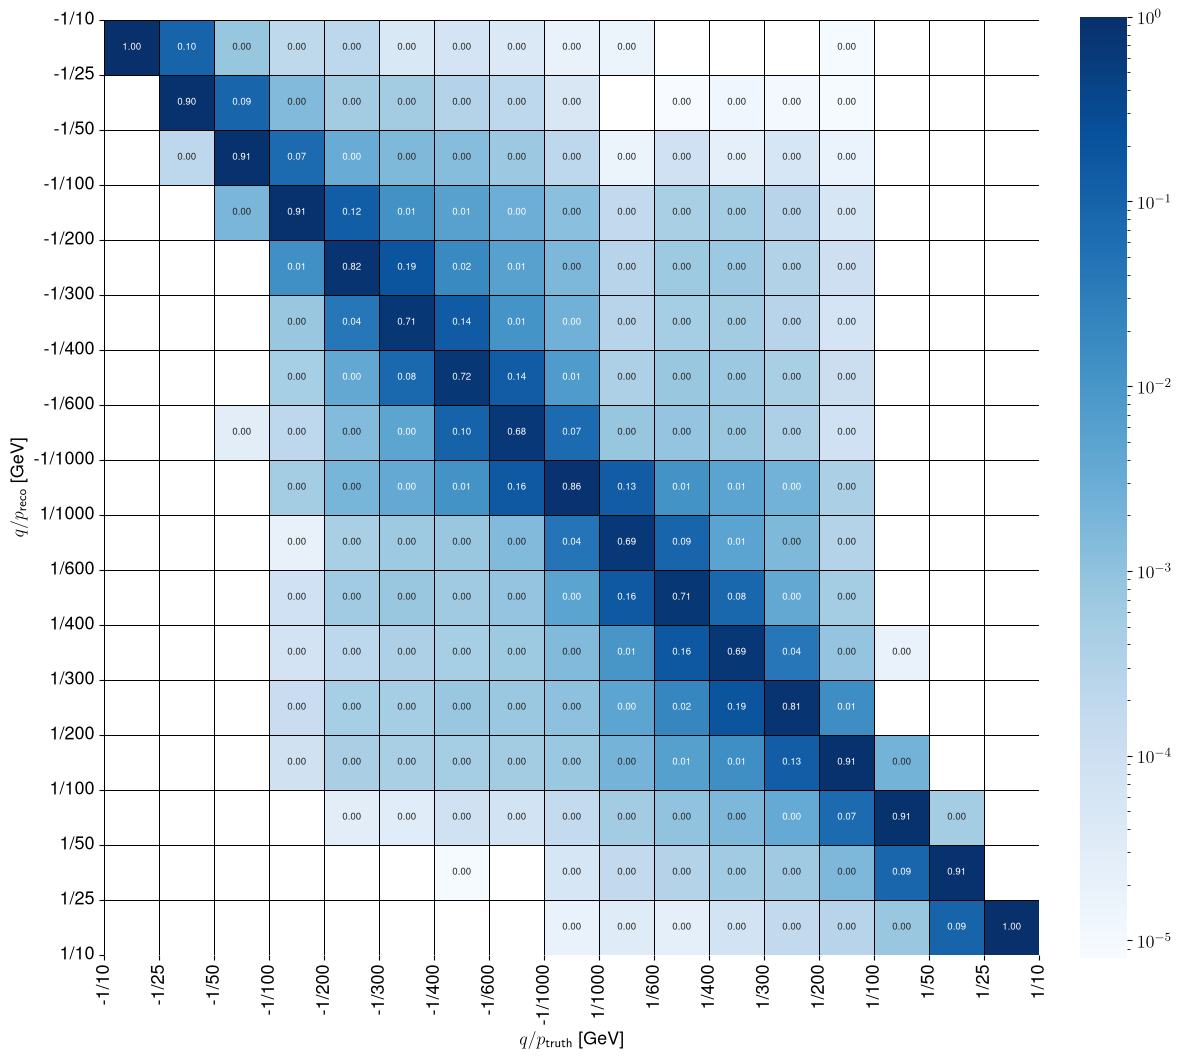

In [12]:
plot_migration_matrix(
    mu_mig,
    xlabel=truth_label,
    ylabel=reco_label,
    norm="log",
    fontsize=7,
    xedges=edges,
    yedges=edges,
    fraction=True,
    figsize=(12, 12),
)

## Initial Guess


In [13]:
# Use pre-fit distribution as initial guess
initial_guess = {"mu": unp.nominal_values(new_mu_flux)}
initial_guess.update(
    {f"theta_mig_{i}": 1e-5 for i in range(num_new_bins * num_new_bins)}
)
# initial_guess.update({f"theta_eff_{i}": 1e-5 for i in range(num_new_bins)})

## Regularization Strength Scan

In [14]:
# Find regularization strength tau, which minimizes the global correlation rho.
# Over-regularization (large tau): regularization forces bins to follow each other -> correlated
# Under-regularization (small tau): Bins are coupled through ill-conditioned migration matrix

rho_results_wide = rho_scan(
    meas=unp.nominal_values(new_mu_flux),
    initial_guess=initial_guess,
    mig=unp.nominal_values(mu_mig),
    mig_unc=unp.std_devs(mu_mig),
    reg_values=np.logspace(-3, 3, 7),
    reg_type="log_curvature",
)

7it [00:13,  1.93s/it]


In [15]:
rho_results_fine = rho_scan(
    meas=unp.nominal_values(new_mu_flux),
    initial_guess=initial_guess,
    mig=unp.nominal_values(mu_mig),
    mig_unc=unp.std_devs(mu_mig),
    reg_values=np.logspace(0, 2, 10),
    reg_type="log_curvature",
)

10it [00:17,  1.72s/it]


In [16]:
# merge and sort rho-results
rho_results = {
    k: np.hstack([rho_results_wide[k], rho_results_fine[k]])
    for k in rho_results_wide.keys()
}
idx = np.argsort(rho_results["reg_values"])
rho_results["reg_values"] = rho_results["reg_values"][idx]
rho_results["rho_values"] = rho_results["rho_values"][idx]

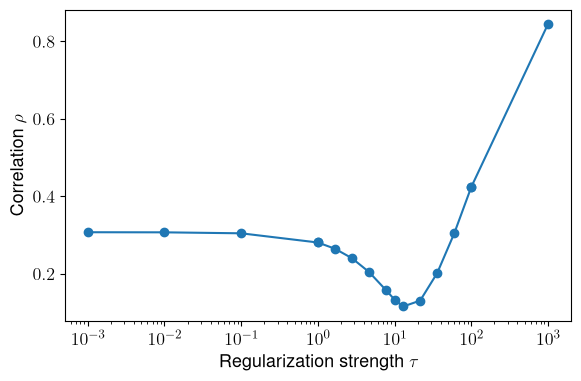

Best regularization strength: 12.9


In [17]:
reg_values = rho_results["reg_values"]
rho_values = rho_results["rho_values"]
plot_rho_scan(reg_values, rho_values)
print(f"Best regularization strength: {reg_values[np.argmin(rho_values)]:.1f}")

## Fit


In [18]:
# default fit with best regularization strength
default_fit = Fit(
    meas=unp.nominal_values(new_mu_flux),
    initial_guess=initial_guess,
    mig=unp.nominal_values(mu_mig),
    mig_unc=unp.std_devs(mu_mig),
    regularization=10,
    reg_type="log_curvature",
)
default_fit_values = default_fit.signal_muarray
nominal_fit_values = unp.nominal_values(default_fit_values)

### Regularization Uncertainty


In [19]:
# Calculate systematic uncertainty from regularization:
# Fit with regularization strength scaled by factor 10 and 0.1, and use max. difference
# to nominal fit as uncertainty.

upper_fit = Fit(
    meas=unp.nominal_values(new_mu_flux),
    initial_guess=initial_guess,
    mig=unp.nominal_values(mu_mig),
    mig_unc=unp.std_devs(mu_mig),
    regularization=100,
    reg_type="log_curvature",
)

lower_fit = Fit(
    meas=unp.nominal_values(new_mu_flux),
    initial_guess=initial_guess,
    mig=unp.nominal_values(mu_mig),
    mig_unc=unp.std_devs(mu_mig),
    regularization=1,
    reg_type="log_curvature",
)

lower_fit_values = lower_fit.signal_muarray
upper_fit_values = upper_fit.signal_muarray
_lower_unc = np.abs(nominal_fit_values - unp.nominal_values(lower_fit_values))
_upper_unc = np.abs(nominal_fit_values - unp.nominal_values(upper_fit_values))
reg_unc = np.max(np.vstack([_lower_unc, _upper_unc]), axis=0)

# Add fit and regularization uncertainty in quadrature
fit_unc = unp.std_devs(default_fit_values)
unc = np.sqrt(fit_unc**2 + reg_unc**2)

pre_fit_values = new_mu_flux
post_fit_values = unp.uarray(nominal_fit_values, unc)

In [20]:
qop_bin_labels = [
    f"[{get_str_fraction(lower)}, {get_str_fraction(upper)}]"
    for (lower, upper) in zip(new_qop_bins[:-1], new_qop_bins[1:])
]
unc_df = pd.DataFrame(
    {
        "Nominal": nominal_fit_values,
        "Rel. fit unc. [%]": fit_unc / nominal_fit_values * 100,
        "Rel. reg. unc. [%]": reg_unc / nominal_fit_values * 100,
    },
    index=qop_bin_labels,
)
display(unc_df.T)

,"[-1/10, -1/25]","[-1/25, -1/50]","[-1/50, -1/100]","[-1/100, -1/200]","[-1/200, -1/300]","[-1/300, -1/400]","[-1/400, -1/600]","[-1/600, -1/1000]","[-1/1000, 1/1000]","[1/1000, 1/600]","[1/600, 1/400]","[1/400, 1/300]","[1/300, 1/200]","[1/200, 1/100]","[1/100, 1/50]","[1/50, 1/25]","[1/25, 1/10]"
Nominal,102.808322,451.034624,810.021654,883.630610,552.202456,550.472598,984.683247,1839.938133,615.198092,404.328358,288.243088,225.534448,378.022578,921.613013,1031.588883,537.854005,111.509447
Rel. fit unc. [%],11.231329,5.053851,3.729933,3.608869,5.053325,5.596807,4.328041,2.913069,5.281645,5.891393,7.090427,7.711205,5.745175,3.484518,3.294711,4.665400,10.929755
Rel. reg. unc. [%],43.984244,6.821418,4.131333,6.479946,11.229131,16.696988,7.590184,17.860310,25.882640,3.166101,5.491966,20.145398,14.614648,6.515247,4.961837,4.258628,47.729946


## Plot Unfolded Muon Flux


### Total Flux


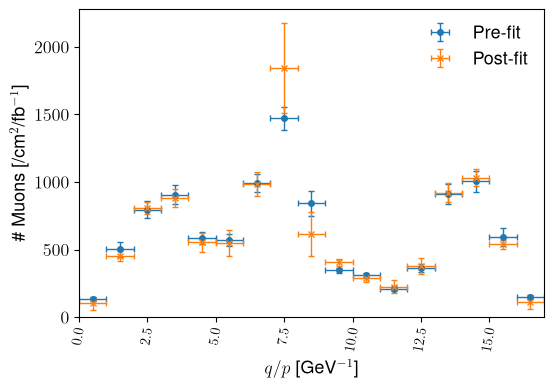

In [21]:
plot_values(
    values=[pre_fit_values, post_fit_values],
    labels=["Pre-fit", "Post-fit"],
    histtypes=["errorbar", "errorbar"],
    edges=np.arange(len(new_qop_bins)),
    edge_value=new_qop_bins,
    markers=["o", "x"],
    markersize=4,
    xlabel=r"$q/p$ [GeV$^{-1}$]",
    fontsize=10,
    rotation=80,
)

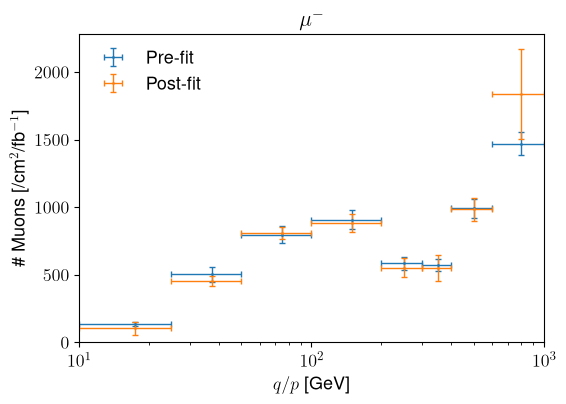

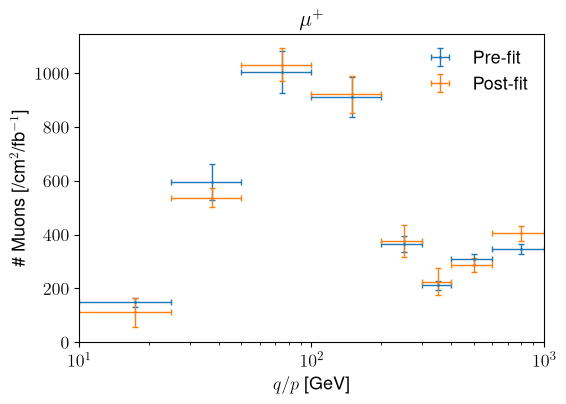

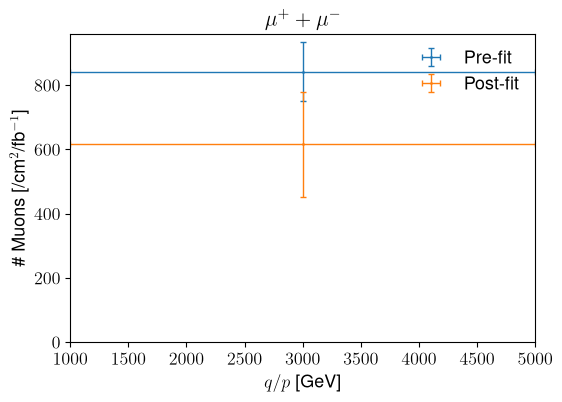

In [22]:
mu_minus_idx = centers < 0
mu_plus_idx = centers > 0
mu_common_idx = centers == 0

pre_fit_mu_minus_flux = pre_fit_values[mu_minus_idx]
post_fit_mu_minus_flux = post_fit_values[mu_minus_idx]

pre_fit_mu_plus_flux = pre_fit_values[mu_plus_idx][::-1]
post_fit_mu_plus_flux = post_fit_values[mu_plus_idx][::-1]

pre_fit_mu_common_flux = pre_fit_values[mu_common_idx]
post_fit_mu_common_flux = post_fit_values[mu_common_idx]

# Neg. charged muons
plot_values(
    values=[pre_fit_mu_minus_flux, post_fit_mu_minus_flux],
    labels=["Pre-fit", "Post-fit"],
    histtypes=["errorbar", "errorbar"],
    edges=new_momentum_bins,
    title=r"$\mu^{-}$",
    xlabel=r"$q/p$ [GeV]",
    xscale="log",
    # yscale="log",
    # ylim=(5e1, 1000),
)

# Pos. charged muons
plot_values(
    values=[pre_fit_mu_plus_flux, post_fit_mu_plus_flux],
    labels=["Pre-fit", "Post-fit"],
    histtypes=["errorbar", "errorbar"],
    edges=new_momentum_bins,
    title=r"$\mu^{+}$",
    xlabel=r"$q/p$ [GeV]",
    xscale="log",
    # yscale="log",
    # ylim=(5e1, 1000),
)

# Common bin
plot_values(
    values=[pre_fit_mu_common_flux, post_fit_mu_common_flux],
    labels=["Pre-fit", "Post-fit"],
    histtypes=["errorbar", "errorbar"],
    edges=[1000, 5000],
    xlabel=r"$q/p$ [GeV]",
    title=r"$\mu^{+} + \mu^{-}$",
    # ylim=(1e-2, 100),
    # xscale="log",
    # yscale="log",
)

### Normalized Flux


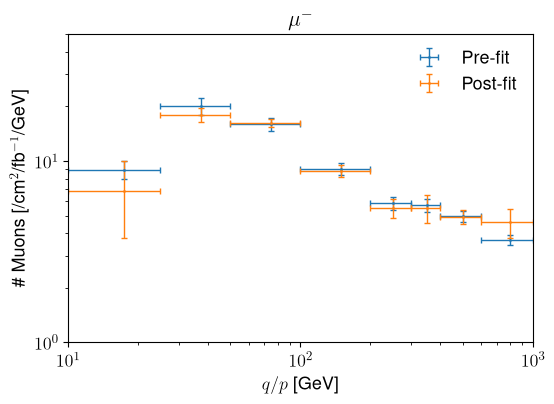

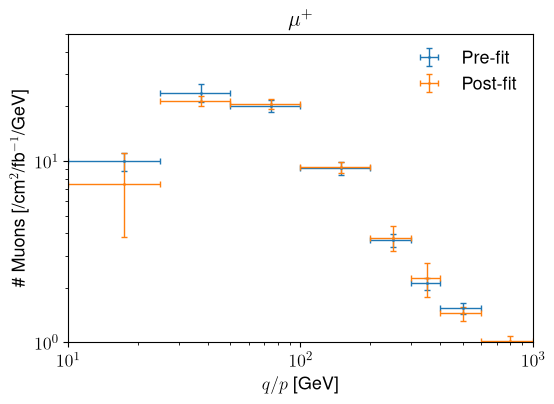

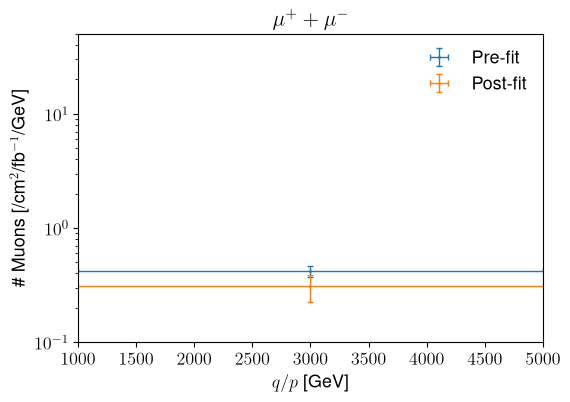

In [23]:
_momentum_bins = new_momentum_bins
_momentum_widths = _momentum_bins[1:] - _momentum_bins[:-1]

norm_pre_fit_mu_minus_flux = pre_fit_mu_minus_flux / _momentum_widths
norm_post_fit_mu_minus_flux = post_fit_mu_minus_flux / _momentum_widths

norm_pre_fit_mu_plus_flux = pre_fit_mu_plus_flux / _momentum_widths
norm_post_fit_mu_plus_flux = post_fit_mu_plus_flux / _momentum_widths

# TODO chose physically motivated bin width for high-energy bin
common_bin_width = 2000  # GeV
norm_pre_fit_mu_common_flux = pre_fit_mu_common_flux / common_bin_width
norm_post_fit_mu_common_flux = post_fit_mu_common_flux / common_bin_width

# Neg. charged muons
plot_values(
    values=[norm_pre_fit_mu_minus_flux, norm_post_fit_mu_minus_flux],
    labels=["Pre-fit", "Post-fit"],
    histtypes=["errorbar", "errorbar"],
    edges=new_momentum_bins,
    title=r"$\mu^{-}$",
    xlabel=r"$q/p$ [GeV]",
    ylabel=r"\# Muons [/cm$^2$/fb$^{-1}$/GeV]",
    xscale="log",
    yscale="log",
    ylim=(1, 50),
)

# Pos. charged muons
plot_values(
    values=[norm_pre_fit_mu_plus_flux, norm_post_fit_mu_plus_flux],
    labels=["Pre-fit", "Post-fit"],
    histtypes=["errorbar", "errorbar"],
    edges=new_momentum_bins,
    title=r"$\mu^{+}$",
    xlabel=r"$q/p$ [GeV]",
    ylabel=r"\# Muons [/cm$^2$/fb$^{-1}$/GeV]",
    xscale="log",
    yscale="log",
    ylim=(1, 50),
)

# Common bin
plot_values(
    values=[norm_pre_fit_mu_common_flux, norm_post_fit_mu_common_flux],
    labels=["Pre-fit", "Post-fit"],
    histtypes=["errorbar", "errorbar"],
    edges=[1000, 5000],
    xlabel=r"$q/p$ [GeV]",
    ylabel=r"\# Muons [/cm$^2$/fb$^{-1}$/GeV]",
    title=r"$\mu^{+} + \mu^{-}$",
    # xscale="log",
    yscale="log",
    ylim=(0.1, 50),
)

## Iminuit output


In [24]:
default_fit.m.params

,Name,Value,Hesse Error,Minos Error-,Minos Error+,Limit-,Limit+,Fixed
0,mu_0,103,11,-11,12,0,,
1,mu_1,451,22,-22,23,0,,
2,mu_2,810,30,-29,30,0,,
3,mu_3,884,32,-31,32,0,,
4,mu_4,552,28,-27,28,0,,
5,mu_5,550,30,-30,31,0,,
6,mu_6,980,40,-40,40,0,,
7,mu_7,1.84e3,0.05e3,-0.05e3,0.05e3,0,,
8,mu_8,615,32,-32,32,0,,
9,mu_9,404,23,-23,24,0,,
